# Processing 2.2 - LNs Intermediate Processing

## Introduction

Here intermediate processing steps for the visium data from LNs are performed including normalization, feature selection, integration and dimensionality reduction.

In [1]:
setwd(here::here())

## Libraries

In [2]:
library(here)
library(glue)
library(tidyverse)
library(BiocParallel)
library(HDF5Array)
library(SpatialExperiment)
library(scuttle)
library(scater)
library(scran)
library(nnSVG)
library(harmony)
library(igraph)
library(dittoSeq)
library(lisi)
library(patchwork)

here() starts at /home/groups/singlecell/cvicente/SP-COVID/visium/0-processing

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: SparseArray

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘p

## Load data

In [3]:
spe <- loadHDF5SummarizedExperiment(
  dir = "out/1-QC_after_spe" %>%
    glue::glue() %>%
    here::here()
)

spe <- spe[, spe$tissue == "lymph-node"]
spe

class: SpatialExperiment 
dim: 30450 11641 
metadata(0):
assays(1): counts
rownames(30450): ENSG00000238009 ENSG00000241860 ... SCoV2_ORF10
  SCoV2_UTR3
rowData names(4): symbol subsets_mito subsets_ribo subsets_SCoV2
colnames(11641): AAACAAGTATCTCCCA-1 AAACAATCTACTAGCA-1 ...
  TTGTTTCACATCCAGG-1 TTGTTTGTGTAAATTC-1
colData names(36): in_tissue array_row ... low_n_features discard
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):
spatialCoords names(2) : pxl_col_in_fullres pxl_row_in_fullres
imgData names(4): sample_id image_id data scaleFactor

## Normalization

In [4]:
spe <- computeLibraryFactors(spe)
summary(sizeFactors(spe))

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.007299 0.639027 0.905520 1.000000 1.227555 5.331591 

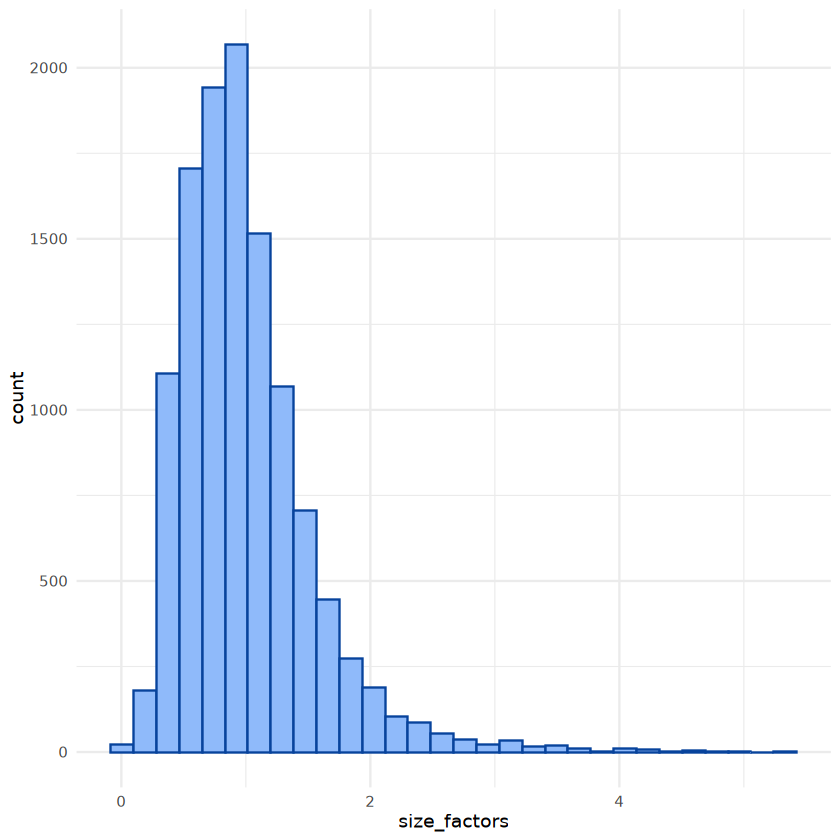

In [5]:
ggplot(data.frame(size_factors = sizeFactors(spe)), aes(x = size_factors)) +
    geom_histogram(fill = "#8fbafa", color = "#07439c", bins = 30) +
    theme_minimal()

In [6]:
spe <- logNormCounts(spe)
assayNames(spe)

[1] "counts"    "logcounts"

## Feature selection

### Highly variable genes(HVGs)
We first remove mitochondrial genes, since these tend to be very highly expressed and are not of main biological interest.

In [7]:
genes <- rowData(spe)$symbol
mt <- grepl("^MT-", genes, ignore.case = TRUE)
table(mt)

spe_mt <- spe[!mt, ]

mt
FALSE  TRUE 
30437    13 

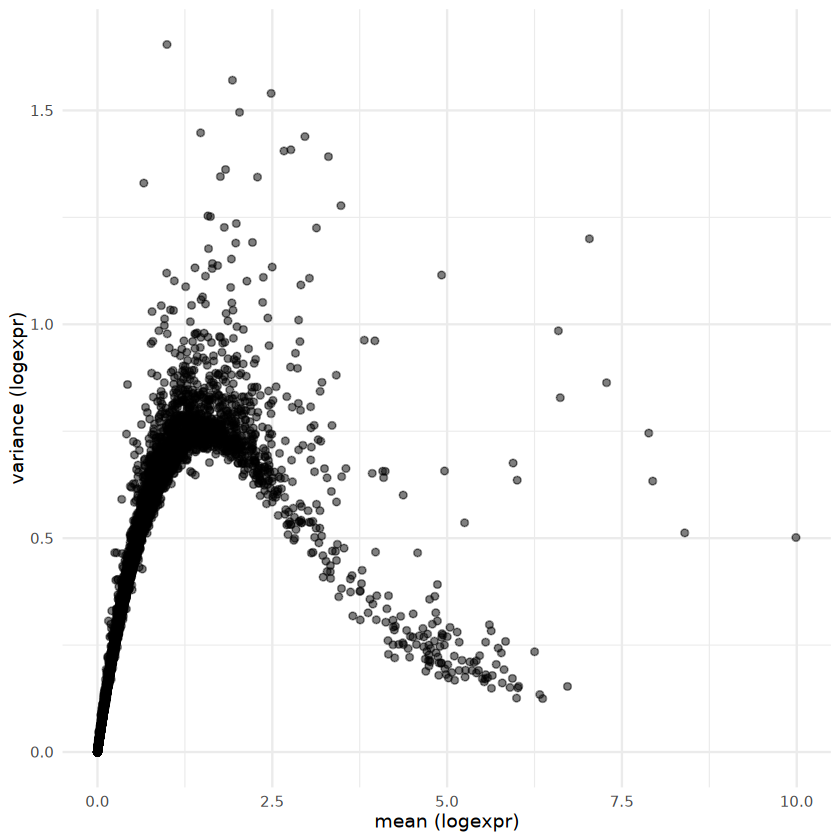

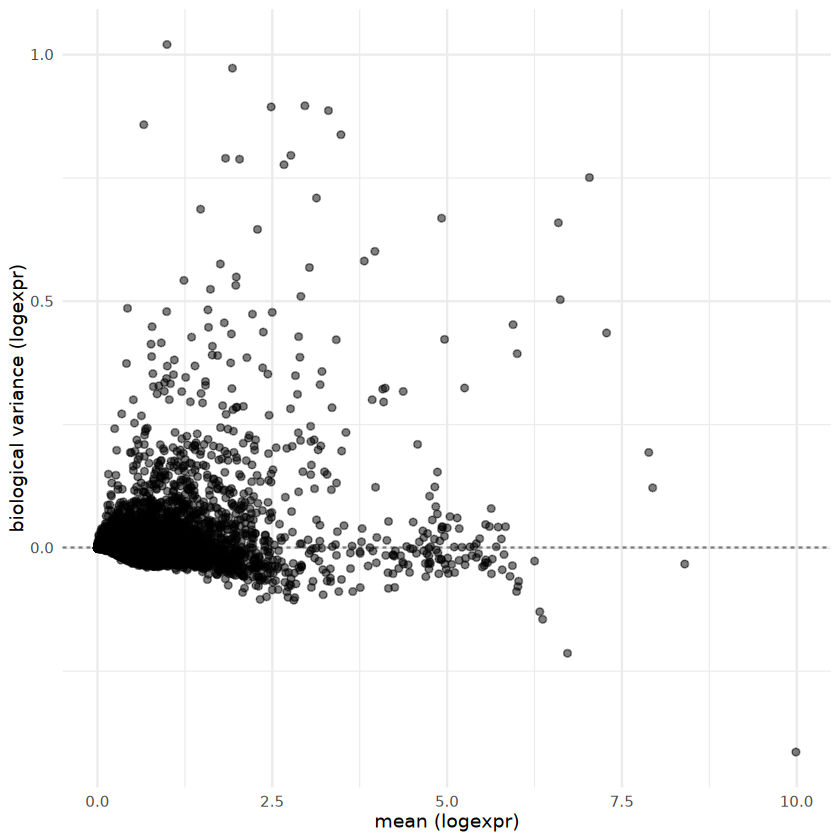

In [8]:
dec <- modelGeneVar(spe_mt, block = spe_mt$study_id)

data.frame(mean = dec$mean, total = dec$total) %>%
    ggplot(aes(x = mean, y = total)) +
    geom_point(alpha = 0.5) +
    labs(x = "mean (logexpr)", y = "variance (logexpr)") +
    theme_minimal()

data.frame(mean = dec$mean, bio = dec$bio) %>%
    ggplot(aes(x = mean, y = bio)) +
    geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
    geom_point(alpha = 0.5) +
    labs(x = "mean (logexpr)", y = "biological variance (logexpr)") +
    theme_minimal()

In [9]:
hvg <- getTopHVGs(dec, prop = 0.1)

cat("\nNumber of top 10% HVGs:\n")
length(hvg)


Number of top 10% HVGs:


[1] 1750

### Spatially variable genes (SVGs)

In [10]:
rowData(spe)$gene_name <- rowData(spe)$symbol

svg_df <- lapply(unique(spe$study_id), function(id){
    set.seed(123)
    sub <- spe[, spe$study_id == id]  
    sub <- filter_genes(sub, filter_genes_ncounts = 10, filter_genes_pcspots = 3)
    
    threshold <- quantile(sub$sum, 0.01)
    keep <- sub$sum > threshold
    
    message("Processing study: ", id)
    message("  Threshold: ", round(threshold), " counts")
    message("  Removing ", sum(!keep), " spots (", 
            round(100*sum(!keep)/length(keep), 1), "%)")
    
    sub <- sub[, keep]
    
    sub <- computeLibraryFactors(sub)
    sub <- logNormCounts(sub)
    
    sub <- nnSVG(sub, n_threads = 16)
    
    return(rowData(sub))
})

Gene filtering: removing mitochondrial genes

removed 13 mitochondrial genes

Gene filtering: retaining genes with at least 10 counts in at least 3% (n = 125) of spatial locations

removed 29982 out of 30437 genes due to low expression

Processing study: control_case_2

  Threshold: 3435 counts

  Removing 42 spots (1%)

Gene filtering: removing mitochondrial genes

removed 13 mitochondrial genes

Gene filtering: retaining genes with at least 10 counts in at least 3% (n = 68) of spatial locations

removed 29830 out of 30437 genes due to low expression

Processing study: acute_case_2

  Threshold: 4002 counts

  Removing 23 spots (1%)

Gene filtering: removing mitochondrial genes

removed 13 mitochondrial genes

Gene filtering: retaining genes with at least 10 counts in at least 3% (n = 87) of spatial locations

removed 29935 out of 30437 genes due to low expression

Processing study: chronic_case_1

  Threshold: 4475 counts

  Removing 29 spots (1%)

Gene filtering: removing mitochondr

In [11]:
svg_sign_df <- lapply(svg_df, function(df) df[df$padj <= 0.05, ])

cat("Number of SVGs per sample:\n")
print(sapply(svg_df, nrow))
cat("\nNumber of significant SVGs per sample:\n")
print(sapply(svg_sign_df, nrow))

cat("\nNumber of significant SVGs:\n")
sum(sapply(svg_sign_df, nrow))

svg <- svg_sign_df %>%
        lapply(rownames) %>% 
        unlist() %>% 
        unique()
                      
cat("\nNumber of unique significant SVGs:\n")
length(svg)

Number of SVGs per sample:
[1] 455 607 502 593

Number of significant SVGs per sample:
[1] 455 581 499 583

Number of significant SVGs:


[1] 2118


Number of unique significant SVGs:


[1] 800

### Merge variable genes

In [12]:
vg <- union(hvg, svg)

cat("\nNumber of merged VGs:\n")
length(vg)


Number of merged VGs:


[1] 2141

## Dimensionality reduction

In [13]:
spe <- runPCA(spe, subset_row = vg)
spe <- runUMAP(spe, dimred = "PCA", n_dimred = 30)

In [14]:
set.seed(123)
g <- buildSNNGraph(spe, use.dimred = "PCA", type = "jaccard", k = 20)

set.seed(123)
k <- cluster_leiden(g, objective_function = "modularity", resolution = 0.5)
spe[["Leiden_res_0.5"]] <- factor(k$membership)

cat("Nº clusters: ", length(unique(k$membership)), "\n")
cat("Spots per cluster: ", table(k$membership), "\n", "\n")

Nº clusters:  7 
Spots per cluster:  2575 1110 476 2887 2249 1926 418 
 


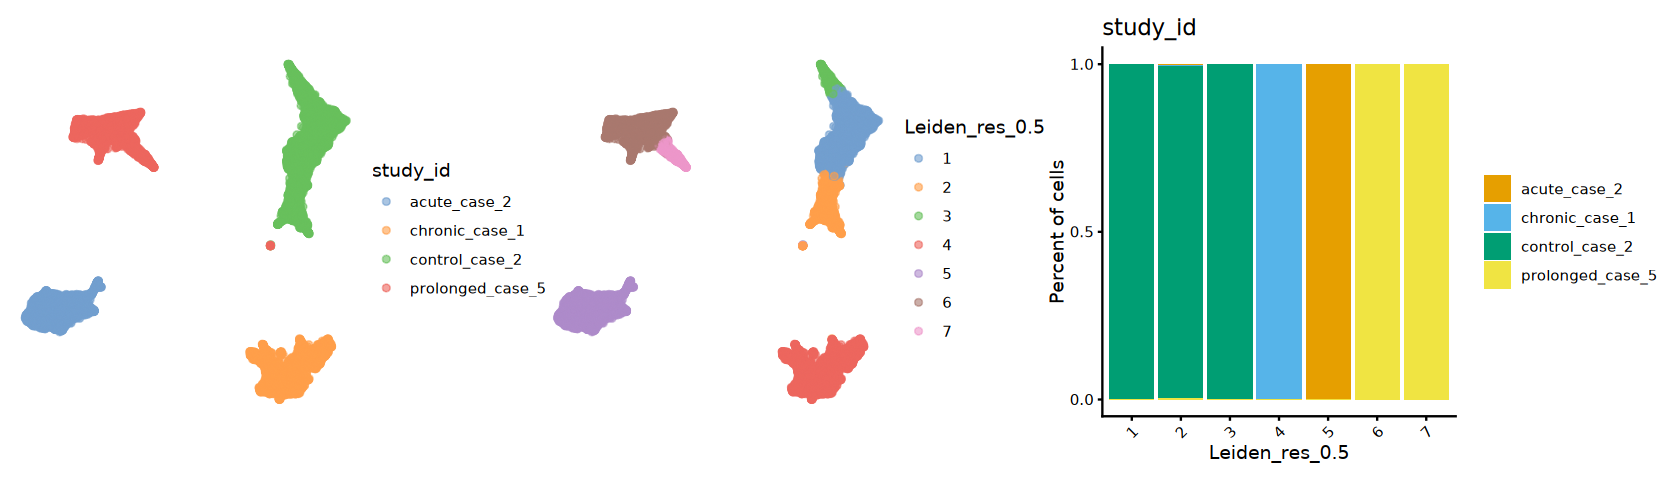

In [16]:
options(repr.plot.width = 14, repr.plot.height = 4, warn = -1)

p1 <- plotReducedDim(spe, dimred = "UMAP", colour_by = "study_id") +
  theme_void()
p2 <- plotReducedDim(spe, dimred = "UMAP", colour_by = "Leiden_res_0.5") +
  theme_void()
p3 <- dittoBarPlot(spe, "study_id", group.by = "Leiden_res_0.5")

p1 | p2 | p3

In [17]:
pca_coords <- reducedDim(spe, "PCA")
metadata <- colData(spe) %>% 
  as.data.frame() %>%
  select(study_id)
lisi_scores <- compute_lisi(pca_coords, metadata, c("study_id"))
spe$lisi_study_id <- lisi_scores$study_id

cat("LISI Score Summary:\n")
cat("Mean LISI:", mean(lisi_scores$study_id), "\n")
cat("Median LISI:", median(lisi_scores$study_id), "\n")
cat("Range:", range(lisi_scores$study_id), "\n\n")

LISI Score Summary:
Mean LISI: 1.004732 
Median LISI: 1 
Range: 1 3.942192 



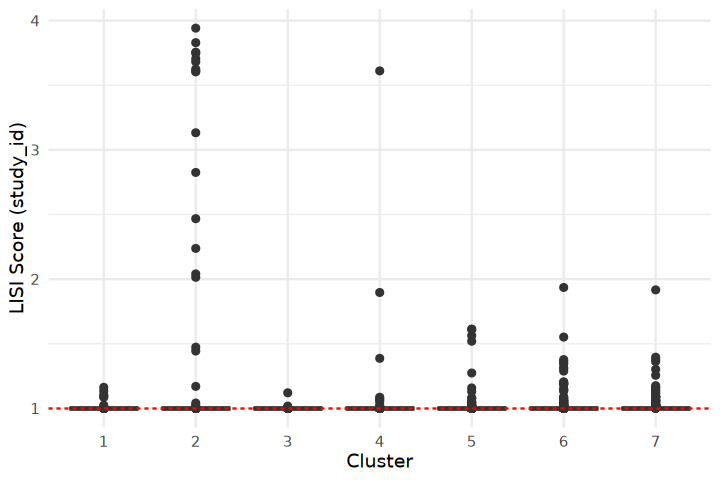

In [18]:
options(repr.plot.width = 6, repr.plot.height = 4, warn = -1)

ggplot(as.data.frame(colData(spe)), 
       aes(x = Leiden_res_0.5, y = lisi_study_id)) +
  geom_boxplot(fill = "lightblue") +
  geom_hline(yintercept = 1, linetype = "dashed", color = "red") +
  labs(x = "Cluster",
       y = "LISI Score (study_id)") +  
  theme_minimal()

We have a clear batch effect by sample so we need to integrate the data.

## Integration

Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony converged after 2 iterations



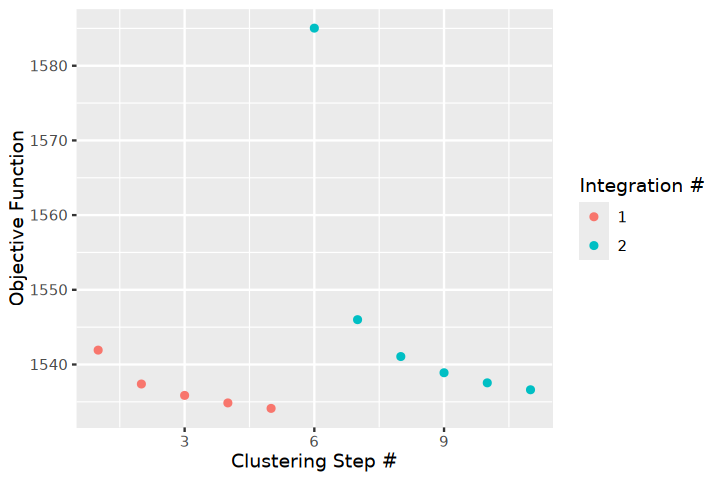

In [19]:
spe <- RunHarmony(spe,
                  group.by.vars = "study_id",
                  reduction = "PCA",
                  reduction.save = "HARMONY",
                  lambda = 0.5,
                  theta = 3,
                  nclust = 30, 
                  plot_convergence = TRUE)

In [20]:
spe <- runUMAP(spe, dimred = "HARMONY", n_dimred = 30)

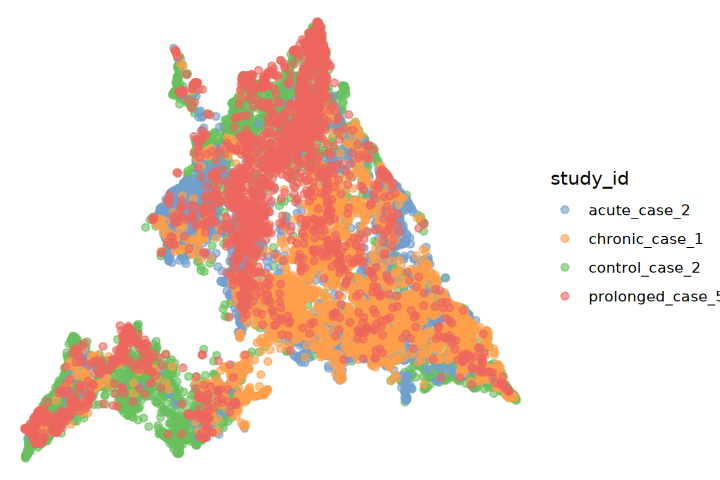

In [21]:
plotReducedDim(spe, dimred = "UMAP", colour_by = "study_id") +
  theme_void() 

## Save data

In [22]:
# save svg
"out/vg/svg_ln.rds" %>%
    glue::glue() %>%
    here::here() %>%
    saveRDS(object = svg, file = .)

# save hvg
"out/vg/hvg_ln.rds" %>%
    glue::glue() %>%
    here::here() %>%
    saveRDS(object = hvg, file = .)

# save vg
"out/vg/vg_ln.rds" %>%
    glue::glue() %>%
    here::here() %>%
    saveRDS(object = vg, file = .)

# save spe processed
saveHDF5SummarizedExperiment(spe, replace = TRUE, dir = "out/2-processed_ln_spe" %>%
                               glue::glue() %>%
                               here::here())

## Session information

In [23]:
sessionInfo()

R version 4.4.3 (2025-02-28)
Platform: x86_64-conda-linux-gnu
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /home/groups/singlecell/cvicente/miniconda3/envs/COVID/lib/libopenblasp-r0.3.29.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Madrid
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] patchwork_1.3.2             lisi_1.0                   
 [3] dittoSeq_1.18.0             igraph_2.2.1               
 [5] harmony_1.2.4               Rcpp_1.1.0                 
 [7] nnSVG_1.1